In [1]:
import matplotlib.pyplot as plt
import pathlib, os, random
import numpy as np
import pandas as pd
import tensorflow as tf
import keras


from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Activation, BatchNormalization, Dropout , GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from keras import Sequential
from keras.callbacks import Callback, EarlyStopping,ModelCheckpoint

C:\Users\coder\new_anaconda\anaconda3\envs\cpu\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
data_dir = pathlib.Path( "C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\9010\\test\\")
BirdClasses = np.array(([item.name for item in data_dir.glob("*")]))
print(BirdClasses)

['babblers bird' 'barbets bird' 'bulbuls bird' 'coots bird' 'cranes bird'
 'cuckoos bird' 'Doves bird' 'Drongos bird' 'Ducks bird' 'Eagles bird'
 'Egrets bird' 'Falcons bird' 'Finches bird' 'Flycatchers bird'
 'Herons bird' 'Hornbills bird' 'Jacanas bird' 'kingfishers bird'
 'munias bird' 'nightjars bird' 'orioles bird' 'owls bird'
 'parakeets bird' 'peafowl bird' 'pesants bird' 'pigeons bird'
 'plovers bird' 'prinias bird' 'robins bird' 'sandpipers bird'
 'shrikes bird' 'storks bird' 'sunbirds bird' 'swallows bird'
 'swamphens bird' 'swifts bird' 'terns bird' 'tits bird' 'wagtails bird'
 'warblers bird' 'woodpeckers bird']


In [3]:
#Model.save("70_30_best_result_non_Segmented_Xception.h5")
new_model1= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\codes\\xception9010.h5")
new_model2= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\codes\\inception_9010.h5")
new_model3= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\codes\\90_10_mobilenetv2.h5")
new_model4= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\codes\\resnet9010.h5")
new_model5= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\codes\\VGG9010.h5")
new_model6= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\codes\\VGG16_9010.h5")
new_model7= tf.keras.models.load_model("C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\codes\\mmep_effecientnetv2_9010.h5")
#new_model8= tf.keras.models.load_model("transformer1.h5")

In [4]:
from transformers import TFViTModel
import tensorflow as tf

new_model8 = tf.keras.models.load_model(
    "C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\codes\\transformer1_9010.h5",
    custom_objects={"TFViTModel": TFViTModel}
)
"""
new_model8.compile(optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, decay=1e-6, momentum=0.9, nesterov=True),
               loss = 'categorical_crossentropy',
              metrics = ['accuracy'])
"""
initial_lr = 0.01
decay_rate = 0.96
decay_steps = 1000

def lr_scheduler(epoch):
    return initial_lr * (decay_rate ** (epoch // decay_steps))

new_model8.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

C:\Users\coder\new_anaconda\anaconda3\envs\cpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir= "C:\\recent caltech\\journal 1\\indian bird dataset\\mmep\\various split\\9010\\test\\"
test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory( test_dir , target_size=(224,224) , batch_size=1 , class_mode = "categorical" ,shuffle=False )
filenames = test_data.filenames
nb_samples = len(filenames)

prediction1 = new_model1.predict(test_data ,steps = nb_samples)

prediction2 = new_model2.predict(test_data ,steps = nb_samples)

prediction3 = new_model3.predict(test_data ,steps = nb_samples)

prediction4 = new_model4.predict(test_data ,steps = nb_samples)

prediction5 = new_model5.predict(test_data ,steps = nb_samples)

prediction6 = new_model6.predict(test_data ,steps = nb_samples)

prediction7 = new_model7.predict(test_data ,steps = nb_samples)

prediction8 = new_model8.predict(test_data ,steps = nb_samples)

Found 328 images belonging to 41 classes.
328/328 [==============================] - 159s 471ms/step


In [6]:
"""test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory( test_dir , target_size=(224,224) , batch_size=1 , class_mode = "categorical" ,shuffle=False )
filenames = test_data.filenames
nb_samples = len(filenames)

prediction = Model.predict(test_data ,steps = nb_samples)
"""

'test_gen = ImageDataGenerator(rescale=1./255)\ntest_data = test_gen.flow_from_directory( test_dir , target_size=(224,224) , batch_size=1 , class_mode = "categorical" ,shuffle=False )\nfilenames = test_data.filenames\nnb_samples = len(filenames)\n\nprediction = Model.predict(test_data ,steps = nb_samples)\n'

In [7]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred = np.argmax(prediction1, axis=1)
#y_pred=np.asarray(prediction)
print('Confusion Matrix')
print(confusion_matrix(test_data.classes, y_pred))
print('Classification Report')
target_names =BirdClasses  
print(classification_report(test_data.classes, y_pred, target_names=BirdClasses))


Confusion Matrix
[[7 0 0 ... 0 0 0]
 [0 8 0 ... 0 0 0]
 [0 0 8 ... 0 0 0]
 ...
 [0 0 0 ... 7 0 0]
 [0 0 0 ... 0 6 0]
 [0 0 0 ... 0 0 5]]
Classification Report
                  precision    recall  f1-score   support

   babblers bird       1.00      0.88      0.93         8
    barbets bird       0.89      1.00      0.94         8
    bulbuls bird       0.89      1.00      0.94         8
      coots bird       0.88      0.88      0.88         8
     cranes bird       0.88      0.88      0.88         8
    cuckoos bird       0.70      0.88      0.78         8
      Doves bird       0.75      0.75      0.75         8
    Drongos bird       0.75      0.75      0.75         8
      Ducks bird       0.78      0.88      0.82         8
     Eagles bird       1.00      0.75      0.86         8
     Egrets bird       1.00      0.88      0.93         8
    Falcons bird       0.50      0.62      0.56         8
    Finches bird       0.80      1.00      0.89         8
Flycatchers bird       0.88 

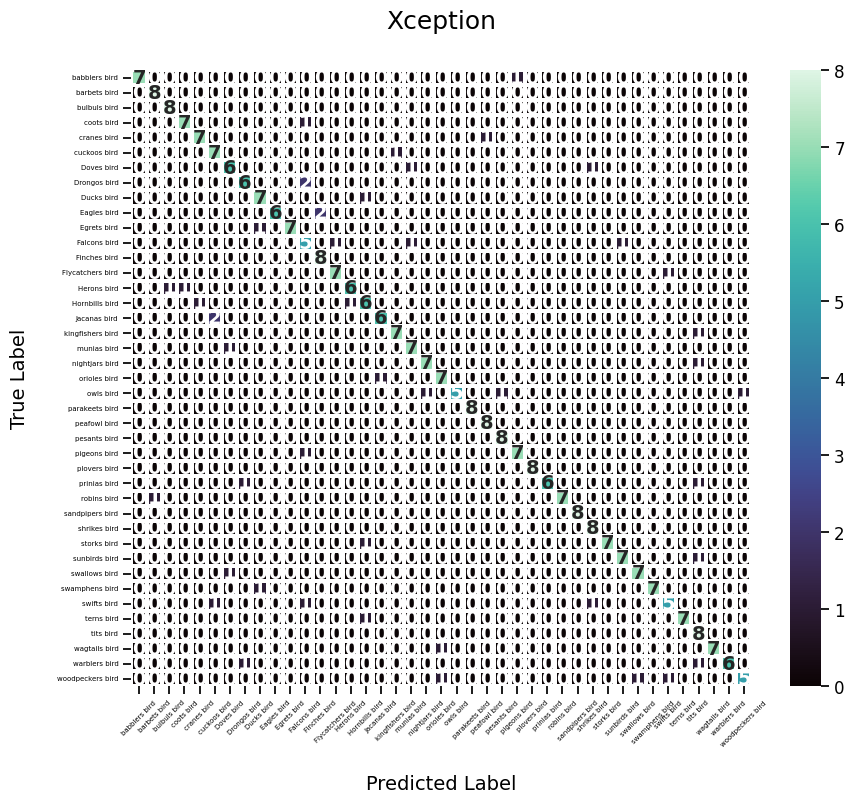

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_fancy_confusion_matrix(x, y_true, y_pred, class_names):
    
    
    
    """
    Predicts and plots a beautiful confusion matrix.
    """
    # 1. Get predictions
    #y_pred_probs = model.predict(X_test)
    #y_pred = np.argmax(y_pred_probs, axis=1)
    
    # If y_true is one-hot encoded, convert to labels
    #if len(y_true.shape) > 1:
    #   y_true = np.argmax(y_true, axis=1)

    # 2. Compute Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # 3. Plotting
    plt.figure(figsize=(10, 8))
    sns.set_context("notebook", font_scale=1.1)
    
    # Using a modern 'mako' or 'rocket' palette for a "dark/tech" look
    # Or stick to 'Blues' for classic professional vibes
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='mako', 
                     annot_kws={"size": 14, "weight": "bold"},
                     xticklabels=class_names, 
                     yticklabels=class_names,
                     linewidths=1.5, linecolor='white')

    # Styling the labels
    plt.xlabel('Predicted Label', fontsize=14, labelpad=20)
    plt.ylabel('True Label', fontsize=14, labelpad=20)
    plt.title(x, fontsize=18, pad=30)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.xticks(fontsize=5)
    plt.yticks(fontsize=5)
    plt.show()

# Example Usage:
# plot_fancy_confusion_matrix(my_model, x_val, y_val, ['Cat', 'Dog', 'Bird'])
#plot_fancy_confusion_matrix(model, X_test, y_true, class_names)
plot_fancy_confusion_matrix('Xception', test_data.classes, y_pred, BirdClasses)

Confusion Matrix
[[7 0 0 ... 0 0 0]
 [0 8 0 ... 0 0 0]
 [0 0 7 ... 0 0 0]
 ...
 [0 0 0 ... 6 1 0]
 [0 0 0 ... 0 6 0]
 [0 0 0 ... 0 0 6]]
Classification Report
                  precision    recall  f1-score   support

   babblers bird       0.78      0.88      0.82         8
    barbets bird       0.89      1.00      0.94         8
    bulbuls bird       1.00      0.88      0.93         8
      coots bird       0.88      0.88      0.88         8
     cranes bird       0.89      1.00      0.94         8
    cuckoos bird       0.86      0.75      0.80         8
      Doves bird       0.57      0.50      0.53         8
    Drongos bird       0.78      0.88      0.82         8
      Ducks bird       0.56      0.62      0.59         8
     Eagles bird       0.88      0.88      0.88         8
     Egrets bird       0.75      0.75      0.75         8
    Falcons bird       0.80      0.50      0.62         8
    Finches bird       0.89      1.00      0.94         8
Flycatchers bird       1.00 

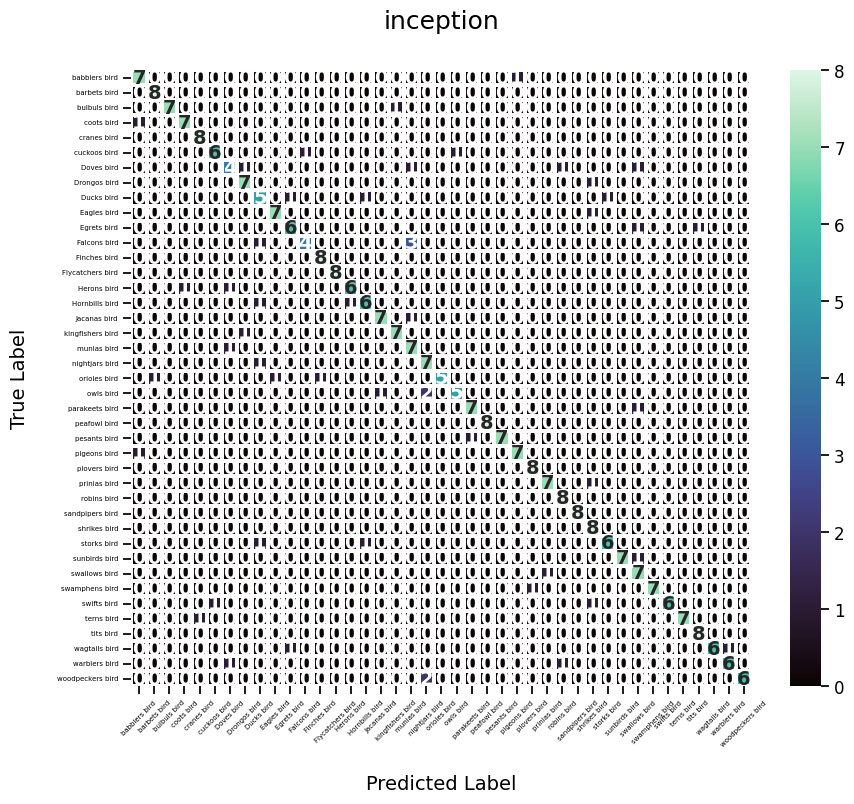

In [9]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred = np.argmax(prediction2, axis=1)
#y_pred=np.asarray(prediction)
print('Confusion Matrix')
print(confusion_matrix(test_data.classes, y_pred))
print('Classification Report')
target_names =BirdClasses  
print(classification_report(test_data.classes, y_pred, target_names=BirdClasses))



plot_fancy_confusion_matrix( 'inception',test_data.classes, y_pred, BirdClasses)

Confusion Matrix
[[7 0 0 ... 0 0 0]
 [0 8 0 ... 0 0 0]
 [0 0 8 ... 0 0 0]
 ...
 [0 1 0 ... 6 1 0]
 [0 0 0 ... 1 5 0]
 [0 0 0 ... 0 0 4]]
Classification Report
                  precision    recall  f1-score   support

   babblers bird       0.70      0.88      0.78         8
    barbets bird       0.89      1.00      0.94         8
    bulbuls bird       1.00      1.00      1.00         8
      coots bird       0.88      0.88      0.88         8
     cranes bird       0.80      1.00      0.89         8
    cuckoos bird       0.89      1.00      0.94         8
      Doves bird       0.78      0.88      0.82         8
    Drongos bird       0.60      0.75      0.67         8
      Ducks bird       0.67      0.75      0.71         8
     Eagles bird       1.00      0.88      0.93         8
     Egrets bird       1.00      0.75      0.86         8
    Falcons bird       1.00      0.75      0.86         8
    Finches bird       0.89      1.00      0.94         8
Flycatchers bird       1.00 

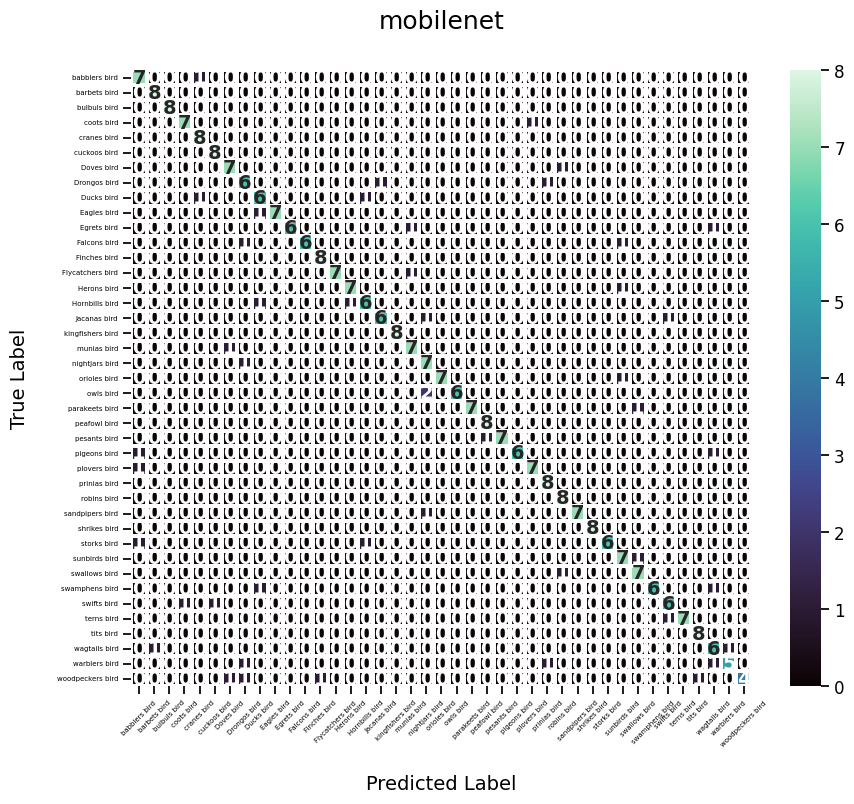

In [10]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred = np.argmax(prediction3, axis=1)
#y_pred=np.asarray(prediction)
print('Confusion Matrix')
print(confusion_matrix(test_data.classes, y_pred))
print('Classification Report')
target_names =BirdClasses  
print(classification_report(test_data.classes, y_pred, target_names=BirdClasses))



plot_fancy_confusion_matrix('mobilenet', test_data.classes, y_pred, BirdClasses)

Confusion Matrix
[[6 0 0 ... 0 0 0]
 [0 8 0 ... 0 0 0]
 [0 0 7 ... 0 0 0]
 ...
 [0 0 0 ... 6 0 1]
 [0 0 0 ... 0 6 0]
 [0 0 0 ... 0 0 6]]
Classification Report
                  precision    recall  f1-score   support

   babblers bird       1.00      0.75      0.86         8
    barbets bird       1.00      1.00      1.00         8
    bulbuls bird       0.88      0.88      0.88         8
      coots bird       0.78      0.88      0.82         8
     cranes bird       0.73      1.00      0.84         8
    cuckoos bird       0.88      0.88      0.88         8
      Doves bird       0.78      0.88      0.82         8
    Drongos bird       0.88      0.88      0.88         8
      Ducks bird       0.62      0.62      0.62         8
     Eagles bird       0.88      0.88      0.88         8
     Egrets bird       1.00      1.00      1.00         8
    Falcons bird       1.00      0.62      0.77         8
    Finches bird       0.89      1.00      0.94         8
Flycatchers bird       0.86 

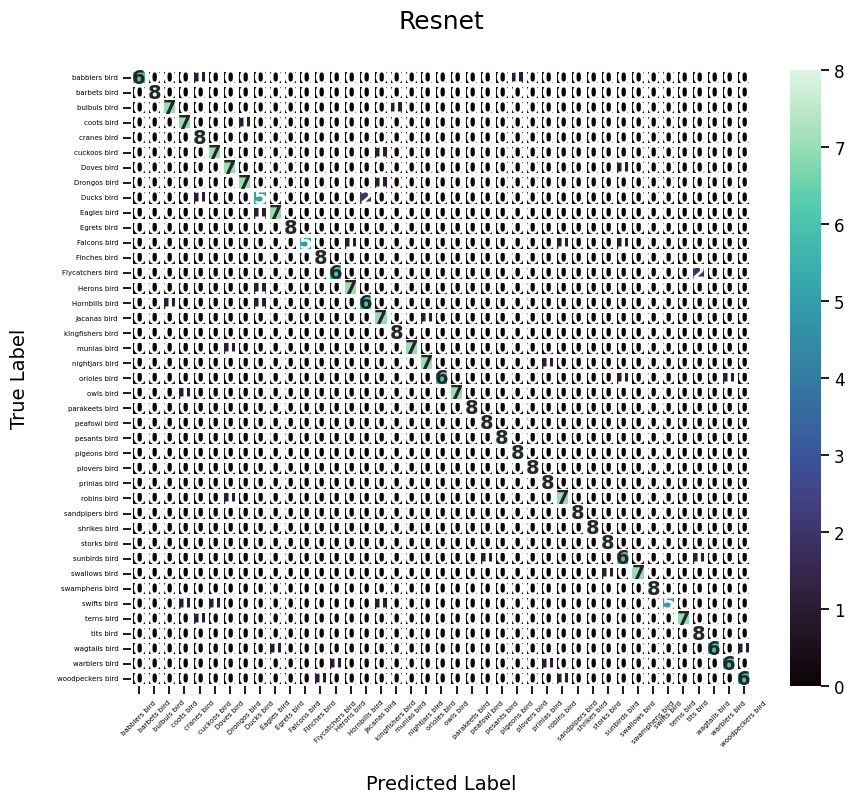

In [11]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred = np.argmax(prediction4, axis=1)
#y_pred=np.asarray(prediction)
print('Confusion Matrix')
print(confusion_matrix(test_data.classes, y_pred))
print('Classification Report')
target_names =BirdClasses  
print(classification_report(test_data.classes, y_pred, target_names=BirdClasses))



plot_fancy_confusion_matrix('Resnet', test_data.classes, y_pred, BirdClasses)

Confusion Matrix
[[7 0 0 ... 0 0 0]
 [0 7 0 ... 0 0 0]
 [0 0 6 ... 0 0 0]
 ...
 [0 0 0 ... 5 2 0]
 [0 0 0 ... 0 6 0]
 [0 0 0 ... 0 0 6]]
Classification Report
                  precision    recall  f1-score   support

   babblers bird       0.88      0.88      0.88         8
    barbets bird       1.00      0.88      0.93         8
    bulbuls bird       0.86      0.75      0.80         8
      coots bird       0.88      0.88      0.88         8
     cranes bird       1.00      0.75      0.86         8
    cuckoos bird       0.86      0.75      0.80         8
      Doves bird       0.64      0.88      0.74         8
    Drongos bird       0.60      0.75      0.67         8
      Ducks bird       0.67      0.75      0.71         8
     Eagles bird       0.88      0.88      0.88         8
     Egrets bird       1.00      1.00      1.00         8
    Falcons bird       1.00      0.62      0.77         8
    Finches bird       1.00      1.00      1.00         8
Flycatchers bird       0.88 

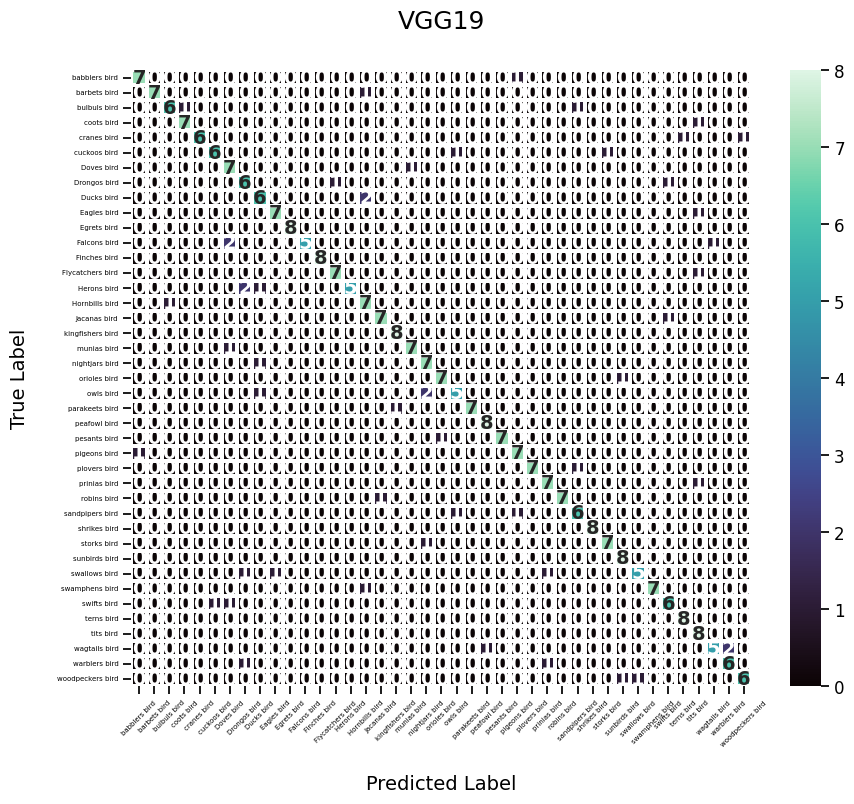

In [12]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred = np.argmax(prediction5, axis=1)
#y_pred=np.asarray(prediction)
print('Confusion Matrix')
print(confusion_matrix(test_data.classes, y_pred))
print('Classification Report')
target_names =BirdClasses  
print(classification_report(test_data.classes, y_pred, target_names=BirdClasses))



plot_fancy_confusion_matrix('VGG19', test_data.classes, y_pred, BirdClasses)

Confusion Matrix
[[6 0 0 ... 0 0 0]
 [0 7 0 ... 0 0 0]
 [0 0 6 ... 0 0 0]
 ...
 [0 0 0 ... 5 2 0]
 [0 0 0 ... 0 6 0]
 [0 0 0 ... 0 0 6]]
Classification Report
                  precision    recall  f1-score   support

   babblers bird       0.86      0.75      0.80         8
    barbets bird       0.88      0.88      0.88         8
    bulbuls bird       0.86      0.75      0.80         8
      coots bird       0.70      0.88      0.78         8
     cranes bird       0.89      1.00      0.94         8
    cuckoos bird       0.78      0.88      0.82         8
      Doves bird       0.67      0.50      0.57         8
    Drongos bird       1.00      0.50      0.67         8
      Ducks bird       0.60      0.75      0.67         8
     Eagles bird       0.88      0.88      0.88         8
     Egrets bird       1.00      0.88      0.93         8
    Falcons bird       1.00      0.62      0.77         8
    Finches bird       0.78      0.88      0.82         8
Flycatchers bird       1.00 

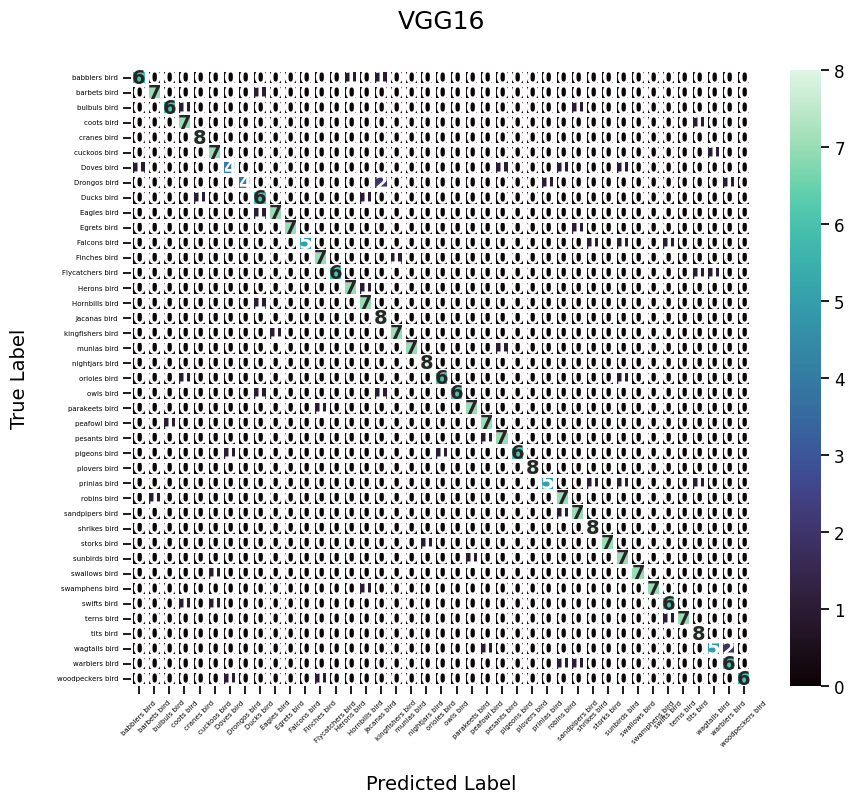

In [13]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred = np.argmax(prediction6, axis=1)
#y_pred=np.asarray(prediction)
print('Confusion Matrix')
print(confusion_matrix(test_data.classes, y_pred))
print('Classification Report')
target_names =BirdClasses  
print(classification_report(test_data.classes, y_pred, target_names=BirdClasses))



plot_fancy_confusion_matrix('VGG16', test_data.classes, y_pred, BirdClasses)

Confusion Matrix
[[8 0 0 ... 0 0 0]
 [0 8 0 ... 0 0 0]
 [0 0 8 ... 0 0 0]
 ...
 [0 0 0 ... 7 0 0]
 [0 0 0 ... 0 7 0]
 [0 0 0 ... 0 0 7]]
Classification Report
                  precision    recall  f1-score   support

   babblers bird       0.89      1.00      0.94         8
    barbets bird       1.00      1.00      1.00         8
    bulbuls bird       1.00      1.00      1.00         8
      coots bird       0.88      0.88      0.88         8
     cranes bird       0.89      1.00      0.94         8
    cuckoos bird       0.88      0.88      0.88         8
      Doves bird       0.71      0.62      0.67         8
    Drongos bird       1.00      1.00      1.00         8
      Ducks bird       0.88      0.88      0.88         8
     Eagles bird       1.00      0.88      0.93         8
     Egrets bird       0.88      0.88      0.88         8
    Falcons bird       0.71      0.62      0.67         8
    Finches bird       0.89      1.00      0.94         8
Flycatchers bird       0.80 

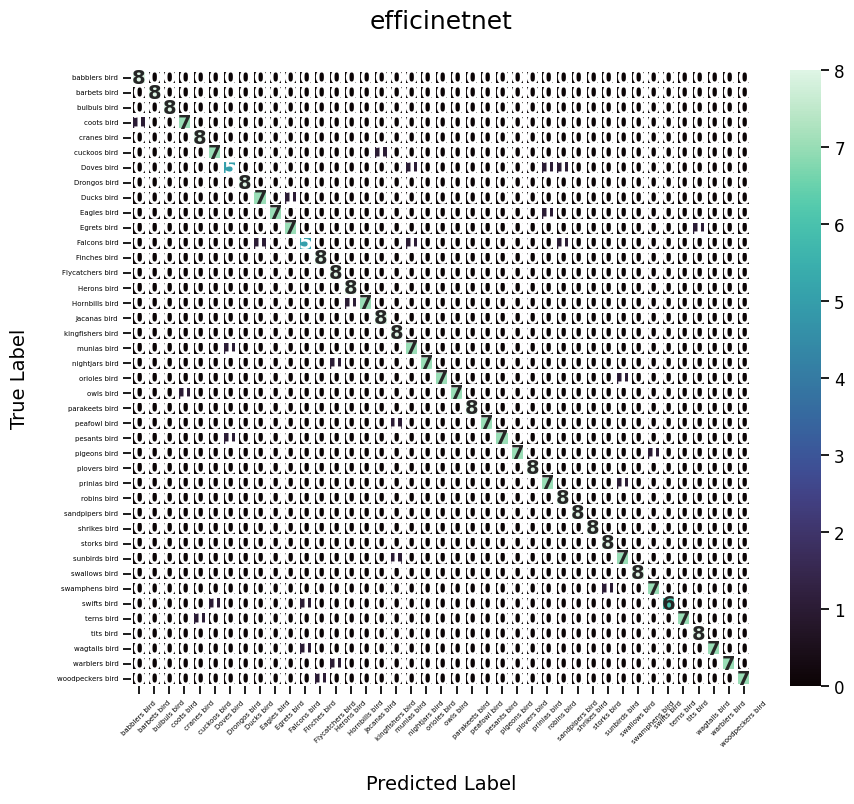

In [14]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred = np.argmax(prediction7, axis=1)
#y_pred=np.asarray(prediction)
print('Confusion Matrix')
print(confusion_matrix(test_data.classes, y_pred))
print('Classification Report')
target_names =BirdClasses  
print(classification_report(test_data.classes, y_pred, target_names=BirdClasses))



plot_fancy_confusion_matrix('efficinetnet', test_data.classes, y_pred, BirdClasses)

Confusion Matrix
[[8 0 0 ... 0 0 0]
 [0 8 0 ... 0 0 0]
 [0 0 8 ... 0 0 0]
 ...
 [0 0 0 ... 7 0 0]
 [0 0 0 ... 0 7 0]
 [0 0 0 ... 0 0 7]]
Classification Report
                  precision    recall  f1-score   support

   babblers bird       0.89      1.00      0.94         8
    barbets bird       1.00      1.00      1.00         8
    bulbuls bird       0.89      1.00      0.94         8
      coots bird       1.00      0.88      0.93         8
     cranes bird       1.00      1.00      1.00         8
    cuckoos bird       1.00      1.00      1.00         8
      Doves bird       0.89      1.00      0.94         8
    Drongos bird       1.00      1.00      1.00         8
      Ducks bird       1.00      0.88      0.93         8
     Eagles bird       1.00      0.88      0.93         8
     Egrets bird       1.00      1.00      1.00         8
    Falcons bird       0.73      1.00      0.84         8
    Finches bird       0.89      1.00      0.94         8
Flycatchers bird       1.00 

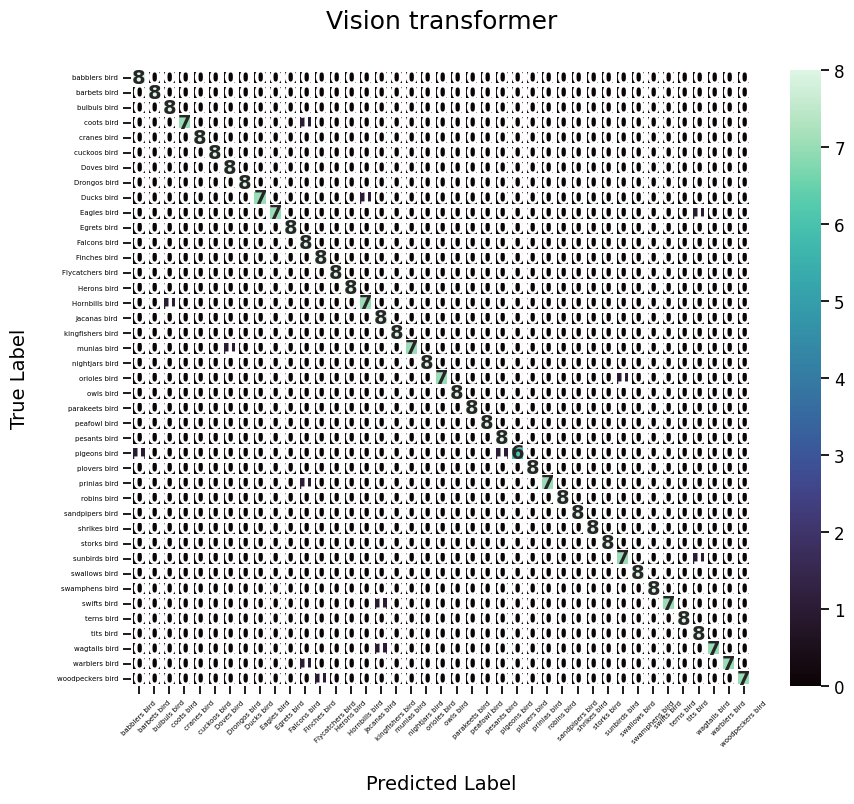

In [15]:
from sklearn.metrics import classification_report, confusion_matrix


y_pred = np.argmax(prediction8, axis=1)
#y_pred=np.asarray(prediction)
print('Confusion Matrix')
print(confusion_matrix(test_data.classes, y_pred))
print('Classification Report')
target_names =BirdClasses  
print(classification_report(test_data.classes, y_pred, target_names=BirdClasses))



plot_fancy_confusion_matrix('Vision transformer', test_data.classes, y_pred, BirdClasses)

In [16]:
y_prediction=[]
print(prediction1)
import numpy as np
y_prediction.append(prediction1)
y_prediction.append(prediction2)
y_prediction.append(prediction3)
y_prediction.append(prediction4)
y_prediction.append(prediction5)
y_prediction.append(prediction6)
y_prediction.append(prediction7)
y_prediction.append(prediction8)

array1=np.array(y_prediction)
array1.shape

[[9.44843948e-01 3.48749134e-04 1.73946377e-04 ... 1.52270195e-05
  2.76284933e-04 1.57219387e-04]
 [8.94518375e-01 5.01584588e-03 9.30340830e-05 ... 3.25978681e-06
  4.70008672e-06 8.72000761e-04]
 [9.59062636e-01 1.03216225e-04 3.68680077e-04 ... 1.35530909e-05
  1.26123385e-04 1.19554905e-04]
 ...
 [4.70656349e-04 3.20742169e-04 3.74604017e-04 ... 1.17122272e-05
  6.38949587e-06 9.86489177e-01]
 [4.15172987e-03 3.09186652e-02 5.66603709e-03 ... 3.32598318e-03
  4.58916202e-02 2.88129896e-01]
 [1.10063651e-04 2.71400408e-04 3.33574251e-04 ... 1.23704004e-03
  6.20865903e-05 1.82895723e-03]]


(8, 328, 41)

In [17]:
import numpy as np
import statistics

def minn(array):
    return min(array)

def maxx(array):
    return(max(array))

def mean(array):
    return statistics.mean(array)

def median(array):
    return statistics.median(array)

def product(array):

    # Multiply elements one by one
    result = 1
    for x in array:
        result = result * x
    return result

def majority(arr):
    m = {}
    for i in range(len(arr)):
        if arr[i] in m:
            m[arr[i]] += 1
        else:
            m[arr[i]] = 1
    #print(m)
    maxx=0
    for i in m:
        #print(i, m[i])
        if maxx<m[i]:
            maxx=m[i]
    for i in m:
        if m[i]==maxx:
            break
    return i









#in this piece of code we will create array of features for different combination
array2=array1
#print(array2)
array2.shape
l2=[]
l1=[]
l3=[]
for i11 in range(len(array2[0])):
    l2=[]
    for i1 in range(len(array2[0][0])):
        l1=[]
        for i in range(len(array2)):
            l1.append(array2[i][i11][i1])
        l2.append(l1)
    l3.append(l2)
#print(l3)





In [18]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np
import numpy
def function1(predicted, y_test):
    x=0
    for i in range(len(predicted)):
        if predicted[i]!=y_test[i]:
            x=x+1
    return( x/len(predicted))


def subfunction(c1,c2, predicted):
    n00,n11,n10,n01=0,0,0,0
    for i in range(len(predicted)):
        if c1[i]==predicted[i] and c2[i]==predicted[i]:
            n11=n11+1
        elif  c1[i]!=predicted[i] and c2[i]==predicted[i]:
            n01=n01+1
        elif  c1[i]==predicted[i] and c2[i]!=predicted[i]:
            n10=n10+1
        elif  c1[i]!=predicted[i] and c2[i]!=predicted[i]:
            n00=n00+1
    value=(n11*n00)-(n01*n10)/((n11*n00)+(n10*n01))
    return value

def function2(P):
    val=0
    L=len(P)
    for i in range(0,L-2):
        for j in range(i,L):
            val=val+subfunction(P[i],P[j],y_test)

    value=(val*2)/((L+1)*(L))
    return value




def binaryToDecimal(n):

    num = n;
    dec_value = 0;

    # Initializing base
    # value to 1, i.e 2 ^ 0
    base = 1;

    temp = num;
    while(temp):
        last_digit = temp % 10;
        temp = int(temp / 10);

        dec_value += last_digit * base;
        base = base * 2;
    return dec_value;

def random_chromozome_generate(p):

  while(True):
      key1 = ""
      for i in range(p):


          temp = str(random.randint(0, 1))


          key1 += temp
      if (binaryToDecimal(int(key1[8:11]))<=5)and (binaryToDecimal(int(key1[8:11]))>0):
            break

  return key1

def mutate(x):
  #print(x)

  x=list(x)


  while(True):
    x1=random.randrange(len(x))
    x=list(x)
    if x[x1]=="0":
      x[x1]="1"
    else:
      x[x1]="0"
    x=''.join(x)
    if binaryToDecimal(int(x[8:11]))<6:
      break
  #x[0]=xy
  return x





def swap(x,y):
  temp = x
  x = y
  y = temp
  return x,y





def crossover(x1,x2):

  while(True):
    xy1=list(x1)
    xy2=list(x2)
    pt1=random.randrange(len(x1))
    for i in range(pt1,len(x1)):
      xy1[i],xy2[i]=swap(xy1[i],xy2[i])
    xy1=''.join(xy1)
    xy2=''.join(xy2)
    p=len(x1)
    if binaryToDecimal(int(xy1[8:11]))<6 and  binaryToDecimal(int(xy2[8:11]))<6 :
      break
  #x1[0]=xy1
  #x2[0]=xy2
  return xy1,xy2






def disect(x,array1):
    p=[]
    #print(x)
    arr=[]
    x=''.join(x)
    for i in range(0,8):
        if x[i]=='1':
            p.append(array1[i])
    #print(x)
    x1= binaryToDecimal(int(x[8:11]))
    #print(x1)
    #print(x1)
    l2=[]
    l1=[]
    l3=[]
    null_vector=[]
    #print(len(p[0]))
    for i in range(len(array1[0])):
        null_vector.append(-1)




    if len(p)==0:
            return null_vector,[]
    #print(p)
    #print(p[0])
    for i12 in range(len(p[0])):

        l2=[]
        for i1 in range(len(p[0][0])):
            l1=[]
            for i in range(len(p)):
                l1.append(p[i][i12][i1])
            l2.append(l1)
        l3.append(l2)
    #print(l3)



    if x1==0:
        #print("Vote")
        a1=[]
        for i in range(len(l3)):
          a2=[]
          for i1 in range(len(l3[0])):
            a2.append(majority(l3[i][i1]))
          a1.append(a2)

        #print(len(a1))
        majority_vector=numpy.argmax(a1, axis=1)
        #print(majority_vector)
        #print(accuracy_score(y_test, majority_vector))
        return majority_vector, p

    elif x1==1:
        #print("max")
        a1=[]
        for i in range(len(l3)):
          a2=[]
          for i1 in range(len(l3[0])):
            a2.append(minn(l3[i][i1]))
          a1.append(a2)

        #print(len(a1))
        min_vector=numpy.argmax(a1, axis=1)
        #print( min_vector)
        #print(accuracy_score(y_test, min_vector))
        return min_vector, p
    elif x1==2:
        #print("min")
        a1=[]
        for i in range(len(l3)):
          a2=[]
          for i1 in range(len(l3[0])):
            a2.append(maxx(l3[i][i1]))
          a1.append(a2)

        #print(len(a1))
        maxx_vector=numpy.argmax(a1, axis=1)
        #print(maxx_vector)
        #print(accuracy_score(y_test, maxx_vector))
        return maxx_vector, p
    elif x1==3:
        #print("mean")
        a1=[]
        for i in range(len(l3)):
          a2=[]
          for i1 in range(len(l3[0])):
            a2.append(mean(l3[i][i1]))
          a1.append(a2)

        #print(len(a1))
        mean_vector=np.argmax(a1, axis=1)
        #print(mean_vector)
        #print(accuracy_score(y_test, mean_vector))
        return mean_vector, p
    elif x1==4:
        #print("median")
        a1=[]
        for i in range(len(l3)):
          a2=[]
          for i1 in range(len(l3[0])):
            a2.append(median(l3[i][i1]))
          a1.append(a2)

        #print(len(a1))
        median_vector=numpy.argmax(a1, axis=1)
        #print(median_vector)
        #print(accuracy_score(y_test, median_vector))
        return median_vector, p
    elif x1==5:
        #print("product")
        a1=[]
        for i in range(len(l3)):
          a2=[]
          for i1 in range(len(l3[0])):
            a2.append(product(l3[i][i1]))
          a1.append(a2)

        #print(len(a1))
        product_vector=numpy.argmax(a1, axis=1)
        #print(product_vector)
        #print(accuracy_score(y_test, product_vector))
        return product_vector, p

    else:
        print("invalid")
"""
# the below code is implementation of the NSGA2
#-------------------------------------------------
#------------------------------------------
#initalise the nasga parameters
pop_size = 20
#max_gen = 921
#generate random population of N chromozomes
chromozome=[]
for i in range(pop_size):
  ch=random_chromozome_generate(11)
  #ch=listtostring(ch)
  chromozome.append(ch)

chromozome.append("00000011100")
chromozome.append("11111111001")
chromozome.append("11111111010")
chromozome.append("11111111011")
chromozome.append("11111111100")
chromozome.append("11111111101")

print(chromozome)
#evalate the objectives of the popluation

fun1=[]
fun2=[]
obj_one=[]

for i in chromozome:
  x=[]
  vector,p=disect(i, array1)
  #p1=numpy.argmax(p,axis=2)
  fun1.append(function1(vector,test_data.classes))
  x.append(i)
  x.append(accuracy_score(vector,test_data.classes))
  obj_one.append(x)

  #print(p)
  #print(vector)
#print(fun1)
#print(fun2)
print(obj_one)
#perform the first two steps i.e.

#non dominated sorting

#crowding distance

#loop
#-----------------------------------------------
#binary tornament selection

#crossover

#mutation

#evaluate the obectives of the offspring

#combine the current popluation and the offspring population

#non dominated sorting

#crowding distancnce

#sorting base on fronts and crowding distance

#select the first N chromozomes as new population of the next genaration

#-------------------------------------------------

#return the perito optimal solutions as soltions of the final output
"""

'\n# the below code is implementation of the NSGA2\n#-------------------------------------------------\n#------------------------------------------\n#initalise the nasga parameters\npop_size = 20\n#max_gen = 921\n#generate random population of N chromozomes\nchromozome=[]\nfor i in range(pop_size):\n  ch=random_chromozome_generate(11)\n  #ch=listtostring(ch)\n  chromozome.append(ch)\n\nchromozome.append("00000011100")\nchromozome.append("11111111001")\nchromozome.append("11111111010")\nchromozome.append("11111111011")\nchromozome.append("11111111100")\nchromozome.append("11111111101")\n\nprint(chromozome)\n#evalate the objectives of the popluation\n\nfun1=[]\nfun2=[]\nobj_one=[]\n\nfor i in chromozome:\n  x=[]\n  vector,p=disect(i, array1)\n  #p1=numpy.argmax(p,axis=2)\n  fun1.append(function1(vector,test_data.classes))\n  x.append(i)\n  x.append(accuracy_score(vector,test_data.classes))\n  obj_one.append(x)\n\n  #print(p)\n  #print(vector)\n#print(fun1)\n#print(fun2)\nprint(obj_one)\n

In [19]:



from sklearn.metrics import classification_report, confusion_matrix
vector,p=disect('00001011011', array2)

y_pred = np.argmax(prediction1, axis=1)
#y_pred=np.asarray(prediction)
print('Confusion Matrix')
print(confusion_matrix(test_data.classes, vector))
print('Classification Report')
target_names =BirdClasses
print(classification_report(test_data.classes, vector, target_names=BirdClasses))

Confusion Matrix
[[8 0 0 ... 0 0 0]
 [0 8 0 ... 0 0 0]
 [0 0 8 ... 0 0 0]
 ...
 [0 0 0 ... 7 0 0]
 [0 0 0 ... 0 8 0]
 [0 0 0 ... 0 0 7]]
Classification Report
                  precision    recall  f1-score   support

   babblers bird       1.00      1.00      1.00         8
    barbets bird       1.00      1.00      1.00         8
    bulbuls bird       1.00      1.00      1.00         8
      coots bird       1.00      0.88      0.93         8
     cranes bird       1.00      1.00      1.00         8
    cuckoos bird       0.89      1.00      0.94         8
      Doves bird       0.89      1.00      0.94         8
    Drongos bird       1.00      1.00      1.00         8
      Ducks bird       1.00      0.88      0.93         8
     Eagles bird       1.00      0.88      0.93         8
     Egrets bird       1.00      1.00      1.00         8
    Falcons bird       0.89      1.00      0.94         8
    Finches bird       0.89      1.00      0.94         8
Flycatchers bird       1.00 

Confusion Matrix
[[8 0 0 ... 0 0 0]
 [0 8 0 ... 0 0 0]
 [0 0 8 ... 0 0 0]
 ...
 [0 0 0 ... 7 0 0]
 [0 0 0 ... 0 8 0]
 [0 0 0 ... 0 0 7]]
Classification Report
                  precision    recall  f1-score   support

   babblers bird       1.00      1.00      1.00         8
    barbets bird       1.00      1.00      1.00         8
    bulbuls bird       1.00      1.00      1.00         8
      coots bird       1.00      0.88      0.93         8
     cranes bird       1.00      1.00      1.00         8
    cuckoos bird       0.89      1.00      0.94         8
      Doves bird       0.89      1.00      0.94         8
    Drongos bird       1.00      1.00      1.00         8
      Ducks bird       1.00      0.88      0.93         8
     Eagles bird       1.00      0.88      0.93         8
     Egrets bird       1.00      1.00      1.00         8
    Falcons bird       0.89      1.00      0.94         8
    Finches bird       0.89      1.00      0.94         8
Flycatchers bird       1.00 

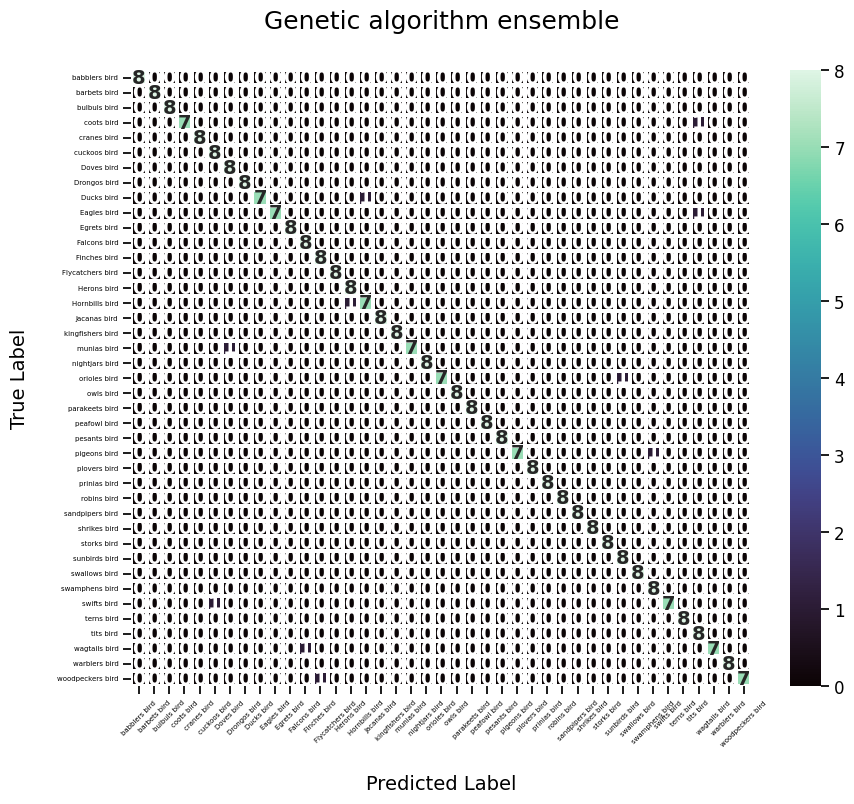

In [20]:

from sklearn.metrics import classification_report, confusion_matrix
vector,p=disect('00001011011', array2)

y_pred = np.argmax(prediction1, axis=1)
#y_pred=np.asarray(prediction)
print('Confusion Matrix')
print(confusion_matrix(test_data.classes, vector))
print('Classification Report')
target_names =BirdClasses
print(classification_report(test_data.classes, vector, target_names=BirdClasses))


plot_fancy_confusion_matrix('Genetic algorithm ensemble', test_data.classes, vector, BirdClasses)